In [36]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.linear_model import LinearRegression
from xgboost import XGBClassifier
import xgboost as xgb
import pickle
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [170]:
!pip install git+https://github.com/Vrboska/mofr@master
import mofr

  Cloning https://github.com/Vrboska/mofr (to revision master) to c:\users\scasny\appdata\local\temp\pip-req-build-02syn9ao
  Resolved https://github.com/Vrboska/mofr to commit 3509aedad3ad1469ec00fecd358b78860d8afb6f
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/Vrboska/mofr 'C:\Users\scasny\AppData\Local\Temp\pip-req-build-02syn9ao'
  Running command git checkout -b master --track origin/master
  branch 'master' set up to track 'origin/master'.
  Switched to a new branch 'master'

[notice] A new release of pip available: 22.3.1 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [389]:
def abs_max_scale(df, column_name):
    """
    Rescale the specified column in the DataFrame using Min-Max scaling,
    keeping negative values intact by scaling between the min and max of the column.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the column to scale.
    column_name (str): The name of the column to be scaled.

    Returns:
    pd.Series: The scaled column as a Pandas Series.
    """
    min_val = df[column_name].min()
    max_val = df[column_name].max()

    # Min-Max Scaling considering the entire range (including negatives)
    scaled_column = df[column_name]/max(abs(min_val), abs(max_val))
    
    return scaled_column

In [602]:
df_data = pickle.load(open(r"C:\develop\EnergyTrading\Python\Strategies\Sparsity_strategy\obt_reg_qmy.pkl", "rb"))
df_data['sparsity_diff'] = df_data['scaled_sparsity'].diff(1)
df_data['ba_spread'] = df_data['a_price'] - df_data['b_price']
df_data = df_data[(df_data['sparsity_diff'] > 0.3) & (df_data['ba_spread'] < 0.16)]
# df_data = df_data[(df_data['trd_gap'] >= 0.02)]
# df_data = df_data[df_data['trd_gap'] <= 0.15]
# df_data = df_data.sample(10000)
l_long_relabel = lambda x: 1 if x > 0 else 0
l_short_relabel = lambda x: 1 if x < 0 else 0
df_data['y_long'] = df_data['y_0.09'].apply(l_long_relabel)
df_data['y_short'] = df_data['y_0.09'].apply(l_short_relabel)

days = df_data['day'].unique()

In [603]:
df_data['iterm_fmXret'] = df_data['lag_return_hat']*df_data['fair_margin']
df_data['iterm_fmXret'] = abs_max_scale(df_data, 'iterm_fmXret')
df_data['iterm_spXbavol'] = df_data['scaled_sparsity']*df_data['ba_volrat_50']
df_data['iterm_spXbavol'] = abs_max_scale(df_data, 'iterm_spXbavol')
df_data = df_data.dropna(subset=feature_cols)


In [272]:
df_data.columns

Index(['timestamp', 'y_0.09', 'delta_a_05', 'delta_a_20', 'delta_b_05',
       'delta_b_20', 'delta_mid_05', 'delta_mid_20', 'ba_volrat_00',
       'ba_volrat_30', 'ba_volrat_50', 'ba_volrat_90', 'diff_am_wm_00',
       'diff_am_wm_30', 'diff_am_wm_50', 'diff_am_wm_90', 'delta_mw_00_05',
       'delta_mw_30_05', 'delta_mw_50_05', 'delta_mw_90_05', 'delta_mw_00_20',
       'delta_mw_30_20', 'delta_mw_50_20', 'delta_mw_90_20',
       'b_price_sparsity', 'a_price_sparsity', 'b_price', 'a_price',
       '_close_level', '_far_level', 'trd_price', 'trd_side', 'trd_gap',
       'last_trade_margin', 'mid', 'p_movement_0.3', 'p_movement_0.5',
       'p_movement_1.0', 'day', 'scaled_sparsity', 'lag_return_hat',
       'fair_margin', 'sparsity_diff', 'ba_spread', 'y_long', 'y_short'],
      dtype='object')

In [492]:
result=[]
for feat in feature_cols:
    gini=mofr.metrics.gini(df_data['y_long'], df_data[feat])
    result.append((feat,gini))
    
pd.DataFrame(result)

,0,1
0,scaled_sparsity,0.038516
1,fair_margin,-0.043829
2,lag_return_hat,0.134811
3,_close_level,0.103589
4,_far_level,0.135163
5,ba_volrat_00,0.039148
6,ba_volrat_50,0.036190
7,p_movement_0.5,0.110389
8,a_price_sparsity,0.052839
9,b_price_sparsity,0.003614


In [604]:
feature_cols = ['scaled_sparsity',
                'fair_margin',
                'lag_return_hat',
                '_close_level',
                '_far_level',
                'ba_volrat_00',
                'ba_volrat_50',
                'p_movement_0.5',
                'a_price_sparsity',
                'b_price_sparsity',
                'iterm_fmXret',
                'iterm_spXbavol']

In [605]:
def df_days_tag(df):
    unique_dates = df['timestamp'].dt.date.unique()
    
    # Create a dictionary to map unique dates to tags
    date_to_tag = {date: tag for tag, date in enumerate(unique_dates)}
    
    # Add a new column for the tags
    df['day'] = df['timestamp'].dt.date.map(date_to_tag)
    
    return df.copy()
tagged_df = df_days_tag(df_data).copy()

In [633]:
train_days = 20
test_days = 1
step = 1
max_day = tagged_df.day.max()
data_set_dict = {range_tuple: {} for range_tuple in [
    (train_start, train_start+(train_days-1), train_start+(train_days+test_days-1)) for train_start in range(
        0, max_day-(train_days+test_days), step)]}
for date_tuple in data_set_dict.keys():
    train_range = range(date_tuple[0], date_tuple[1]+1)
    test_range = range(date_tuple[1]+1, date_tuple[2]+1)

    data_set_dict[date_tuple]['train'] = tagged_df[tagged_df['day'].isin(train_range)]
    data_set_dict[date_tuple]['test'] = tagged_df[tagged_df['day'].isin(test_range)]

In [532]:
l_long_relabel = lambda x: 1 if x > 0 else 0
l_short_relabel = lambda x: 1 if x < 0 else 0
l_neu_relabel = lambda x: 1 if x < 0.5 and x > -0.5 else 0
def idx_max_thold(array, thold_for, thold_against):
    new_array = np.array(array)/sum(array)
    best, sbest = sorted([(v, i) for i, v in enumerate(new_array)], reverse=True)[:2]
    b_sb_diff = best[0] - sbest[0]
    return best[1] if (array[best[1]] > thold_for) and (b_sb_diff > thold_against) else 1

In [533]:
idx_max_thold([0.65, 0.1, 0.1], 0.6, 0.1)

0

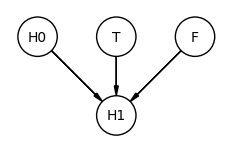

In [711]:
import matplotlib.pyplot as plt
import networkx as nx
import daft

def draw_dag(dag, coordinates):
    pgm = daft.PGM()
    for node in dag.nodes:
        pgm.add_node(node, node, *coordinates[node])
    for edge in dag.edges:
        pgm.add_edge(*edge)
    pgm.render()
    plt.gca().invert_yaxis()

# Create a DAG using networkx
dag = nx.DiGraph()
dag.add_edges_from([("H0", "H1"), ("F", "H1"), ("T", "H1")])

coordinates = {"H0": (0, 0), "T": (1, 0), "F": (2, 0), "H1": (1, 1)}

# Plot the DAG using the draw_dag function
draw_dag(dag, coordinates)
plt.show()


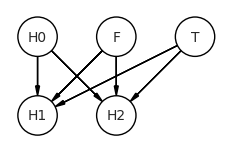

In [744]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import daft

def generate_coordinates(dag):
    # Topologically sort the nodes to respect dependencies
    sorted_nodes = list(nx.topological_sort(dag))
    
    # Dictionary to store y-level of each node
    layer_map = {}
    # Dictionary to store x, y coordinates
    coordinates = {}
    
    # Track which nodes are on each y-level
    layer_nodes = {}
    
    # Assign layers (y-level) based on dependencies
    for node in sorted_nodes:
        # Get the maximum y-level of its predecessors
        predecessors = list(dag.predecessors(node))
        if predecessors:
            max_layer = max(layer_map[predecessor] for predecessor in predecessors)
            layer = max_layer + 1
        else:
            # No predecessors, place on layer 0
            layer = 0
        
        # Update layer_map and track nodes on this layer
        layer_map[node] = layer
        if layer not in layer_nodes:
            layer_nodes[layer] = []
        layer_nodes[layer].append(node)
    
    # Assign x-coordinates based on the number of nodes in each layer
    for layer, nodes in layer_nodes.items():
        n = len(nodes)
        x_positions = np.linspace(0, n-1, n)  # Evenly space nodes in the layer
        for i, node in enumerate(nodes):
            coordinates[node] = (x_positions[i], -layer)  # y = -layer to invert y-axis for drawing
    
    return coordinates

# Modify the existing draw_dag function
def draw_dag(dag, coordinates):
    pgm = daft.PGM()
    for node in dag.nodes:
        pgm.add_node(node, node, *coordinates[node])
    for edge in dag.edges:
        pgm.add_edge(*edge)
    pgm.render()
#     plt.gca().invert_yaxis()

# Create a DAG using networkx
dag = nx.DiGraph()
dag.add_edges_from([("H0", "H1"), ("F", "H1"), ("T", "H1"), ("H0", "H2"), ("F", "H2"), ("T", "H2")])

# Generate coordinates automatically
coordinates = generate_coordinates(dag)

# Plot the DAG using the draw_dag function
draw_dag(dag, coordinates)
plt.show()


In [718]:
import numpy as np
import networkx as nx

# Example model functions for each node, taking input X and returning an output
def model_H0(X):
    print("Running model H0")
    return X[0]  # Example calculation

def model_H1(X, outputs_from_parents):
    print("Running model H1")
    stacked_output = np.stack(outputs_from_parents, axis=0)  # Stack the outputs from the parent nodes
    return np.max(stacked_output, axis=0)  # Example calculation using stacked outputs

def model_F(X):
    print("Running model F")
    return X[1]  # Example calculation

def model_T(X):
    print("Running model T")
    return X[2]  # Example calculation

# Dictionary of model functions corresponding to each node
model_functions = {
    "H0": model_H0,
    "H1": model_H1,
    "F": model_F,
    "T": model_T,
}

# DAG definition (Directed Acyclic Graph)
dag = nx.DiGraph()
dag.add_edges_from([("H0", "H1"), ("F", "H1"), ("T", "H1")])

coordinates = {"H0": (0, 0), "T": (1, 0), "F": (2, 0), "H1": (1, 1)}

# Topological sort of the DAG based on dependencies (arrows)
sorted_nodes = list(nx.topological_sort(dag))

# Dictionary to store the outputs of each node
outputs = {}

# Input vector X
X = np.array([1, 2, 3])  # Example input

# Loop through the topologically sorted nodes and run each corresponding model function
for node in sorted_nodes:
    # If the node has parents, gather their outputs and pass to the model function
    if list(dag.predecessors(node)):
        parent_outputs = [outputs[parent] for parent in dag.predecessors(node)]
        outputs[node] = model_functions[node](X, parent_outputs)  # Pass X and parent outputs to H1
    else:
        outputs[node] = model_functions[node](X)  # For nodes without parents, just pass X

# The final output of H1 can be seen in outputs['H1']
print("Final output from H1:", outputs["H1"])


Running model H0
Running model F
Running model T
Running model H1
Final output from H1: 3


In [716]:
sorted_nodes

['H0', 'F', 'T', 'H1']

Daily Precision 0.4924936396002006
Overal precision 0.5317779565567177
EV sum -71.49999999999997
Average count 36.55882352941177
Active days:  34 / 41


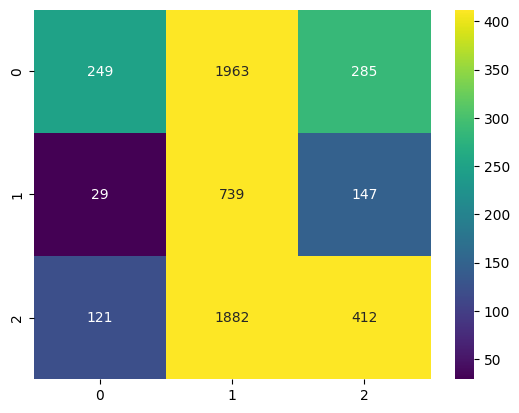

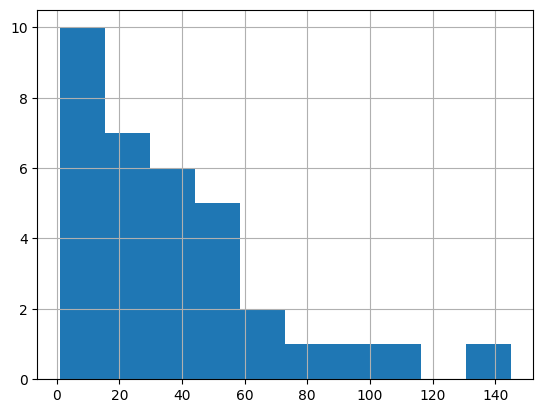

<Axes: >

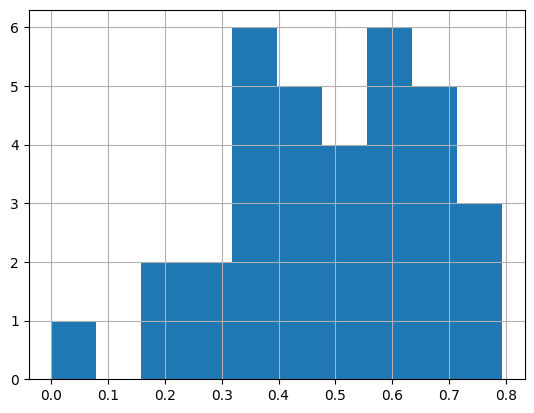

In [696]:
# def idx_max_thold(array, thold):
#     return pd.Series(array).idxmax() if max(array) > thold else 1
import matplotlib.pyplot as plt
l_relabel_comb = lambda x: 2 if x > 0.5 else 0 if x < -0.5 else 1
# 0.68 precision
# MAX_DEPTH = 2
# N_TREES = 15
# THOLD_FOR = 0.62
# THOLD_AGAINST = 0.45
# SUBSAMPLE = 1
# COLSAMPLE = 1
# GAMMA = 0
# MIN_CH = 0
# LAMBDA = 0
# ALFA = 0
# ETA = 0.25
# 0.64 3	10	0.7	0.35	1	1	0	0	0
# 0.63 2	50	0.55	0.45	1	1	0	0	1
# 0.63 3	10	0.67	0.4	1	1	0	0	0	0.25
# 0.65 3	10	0.67	0.45	1	1	0	0	0	0.25
# 0.67 2	30	0.7	0.25	1	1	0	0	0	0.17
# 


MAX_DEPTH = 2
N_TREES = 2
THOLD_FOR = 0.4
THOLD_AGAINST = 0.2
SUBSAMPLE = 1
COLSAMPLE = 1
GAMMA = 0
MIN_CH = 0
LAMBDA = 0
ALFA = 0
ETA = 0.25
xx = {}
models = {
    'long': [],
    'neutral': [],
    'short': []
}
heatmap = np.zeros((3,3))
for key, data in data_set_dict.items():
    train = data['train'].copy()
    test = data['test'].copy()

    xgb_model_long = XGBClassifier(objective='binary:logistic', max_depth=MAX_DEPTH, n_estimators=N_TREES, subsample=SUBSAMPLE, colsample_bytree=COLSAMPLE,
                                  gamma=GAMMA, min_child_weight=MIN_CH, reg_lambda=LAMBDA, reg_alpha=ALFA, learning_rate=ETA)
    xgb_model_long.fit(train[feature_cols],
                  train['y_0.09'].apply(l_long_relabel))

    preds_long = xgb_model_long.predict_proba(test[feature_cols])[:,1]

    xgb_model_short = XGBClassifier(objective='binary:logistic', max_depth=MAX_DEPTH, n_estimators=N_TREES, subsample=SUBSAMPLE, colsample_bytree=COLSAMPLE,
                                  gamma=GAMMA, min_child_weight=MIN_CH, reg_lambda=LAMBDA, learning_rate=ETA)
    xgb_model_short.fit(train[feature_cols],
                  train['y_0.09'].apply(l_short_relabel))

    preds_short = xgb_model_short.predict_proba(test[feature_cols])[:,1]

    xgb_model_neu = XGBClassifier(objective='binary:logistic', max_depth=MAX_DEPTH, n_estimators=N_TREES, subsample=SUBSAMPLE, colsample_bytree=COLSAMPLE,
                                  gamma=GAMMA, min_child_weight=MIN_CH, reg_lambda=LAMBDA, learning_rate=ETA)
    xgb_model_neu.fit(train[feature_cols],
                  train['y_0.09'].apply(l_neu_relabel))

    preds_neu = xgb_model_neu.predict_proba(test[feature_cols])[:,1]

    preds_comb = np.stack((preds_short, preds_neu, preds_long), axis=1)

    result = {'p_short': [], 'p_neu': [], 'p_long': [],'count': [], 'count_short': [],'count_long': [], 'ev': [], 'w_p': []}

    preds = [idx_max_thold(x, THOLD_FOR, THOLD_AGAINST) for x in preds_comb]
    cm = confusion_matrix(test['y_0.09'].apply(l_relabel_comb), preds, labels=[0, 1, 2])
    
    long_TP = cm[2, 2]  # Actual positive (1) and predicted positive (1)
    long_FP = cm[0, 2] + cm[1, 2] # Actual negative (0) but predicted positive (1)

    short_TP = cm[0, 0]  # Actual positive (1) and predicted positive (1)
    short_FP = cm[1, 0] + cm[2, 0] # Actual negative (0) but predicted positive (1)

    neu_TP = cm[1, 1]  # Actual positive (1) and predicted positive (1)
    neu_FP = cm[0, 1] + cm[2, 1] # Actual negative (0) but predicted positive (1)
    
    long_count = long_TP + long_FP
    short_count = short_TP + short_FP
    long_precision = long_TP / long_count if long_count > 0 else 0
    short_precision = short_TP / short_count if short_count > 0 else 0
    neu_precision = neu_TP / (neu_TP + neu_FP) if (neu_TP + neu_FP) > 0 else 0


    result['p_short'].append(short_precision)
    result['p_neu'].append(neu_precision)
    result['p_long'].append(long_precision)
    result['count_short'].append(short_count)
    result['count_long'].append(long_count)
    result['count'].append(long_count+short_count)
    
    models['long'].append(xgb_model_long)
    models['neutral'].append(xgb_model_neu)
    models['short'].append(xgb_model_short)

    ev = expected_value(long_precision, long_count ) + expected_value(short_precision, short_count)
    result['ev'].append(ev)
    
    result['w_p'].append((long_precision*long_count + short_precision*short_count)/(long_count+short_count) if (long_count+short_count) > 0 else 0)
    

    df_max = pd.DataFrame(result)
    df_max = df_max.iloc[df_max['ev'].idxmax()].to_dict()
    xx[key] = df_max
    heatmap += cm
df_res = pd.DataFrame(xx).T
df_res['count_wp'] = df_res['count']*df_res['w_p']

import seaborn as sns
sns.heatmap(heatmap, annot=True, fmt='.0f', cmap='viridis',
            vmax=max(heatmap[:, 0].max(), heatmap[:, 2].max()))
print("Daily Precision", df_res[df_res['count'] > 0]['w_p'].mean())
print("Overal precision", (df_res['count_wp'].sum()/df_res['count'].sum()))
print("EV sum", df_res['ev'].sum())
print("Average count", df_res[df_res['count'] != 0]['count'].mean())
print("Active days: ", sum(df_res['count'] > 0) , "/", len(data_set_dict))
plt.show()
df_res[df_res['count'] > 0]['count'].hist()
plt.show()
df_res[df_res['count'] > 0]['w_p'].hist()

In [ ]:
!pip install arviz
import arviz as az
az.style.use("arviz-darkgrid")
az.rcParams["stats.hdi_prob"] = 0.89  # sets default credible interval used by arviz

> **2 out High density interval**

In [730]:
l_precision = lambda df: df['count_wp'].sum()/df['count'].sum()
az.hdi(np.array([l_precision(df_res.sample(df_res.shape[0]-2)) for _ in range(100)])).shape

(2,)

In [679]:
df_data[feature_cols[0]].quantile(0.1)

-0.28138617963424334

In [ ]:
quantiles = [0.1, 0.3, 0.5, 0.7, 0.9]


In [697]:
# Save the model (trees and structure) as JSON
models['long'][0].get_booster().save_model(r"Z:\XGBModels\xgbmodel_0.json")

# Save the model configuration to include all parameters (learning rate, etc.)
config = models['long'][0].get_booster().save_config()

# Write the configuration to a JSON file (with learning rate and other params)
with open(r"Z:\XGBModels\xgbmodel_0_config.json", 'w') as f:
    f.write(config)

In [698]:
models['long'][0].predict([[0.1, -0.1, 1.5, 0.1, 0.2, -0.2, -0.5, 0.6, 0.1, 0.4, 0.78, 0.6]], output_margin=True)

array([-0.7074748], dtype=float32)

In [700]:
models['long'][0].feature_importances_

array([0.11631479, 0.        , 0.14324726, 0.22594859, 0.        ,
       0.        , 0.31013286, 0.20435645, 0.        , 0.        ,
       0.        , 0.        ], dtype=float32)

In [675]:
pred = model['long'][0].predict(Xd, output_margin=True)

explainer = shap.TreeExplainer(model)
explanation = explainer(Xd)

shap_values = explanation.values

ImportError: cannot import name 'if_delegate_has_method' from 'sklearn.utils.metaestimators' (C:\develop\EnergyTrading\env\Lib\site-packages\sklearn\utils\metaestimators.py)

In [141]:
def idx_max_thold(array, thold):
    return pd.Series(array).idxmax() if max(array) > thold else 1

def expected_value(precision, count):
    PROFIT_ = 0.2
    LOSS_ = 0.35
    return (count*precision*PROFIT_)-(count*(1-precision)*LOSS_)

def multivar_model(data_test):
    thold = [0.5, 0.05, 0.2]
    cols = ['scaled_sparsity', 'fair_margin', 'lag_return_hat']
    feature_increase = [True, True, True]
    result = [2 if eval_comb(
        [x[y] for y in cols], thold, feature_increase
    ) else 1 for x in data_test.to_dict(orient='records')]
    return result

def eval_comb(comb, thold, increase_list):
    result = True
    for c, th, inc in zip(comb, thold, increase_list):
        result &= (lambda x, thold, inc: x > thold if inc else x < thold
                       )(c, th, inc)
    return result
    

l_relabel_comb = lambda x: 2 if x > 0.5 else 0 if x < -0.5 else 1

MAX_DEPTH = 3
N_TREES = 4
THOLD = 0.65
SUBSAMPLE = 1
COLSAMPLE = 1
GAMMA = 0
MIN_CH = 0
LAMBDA = 0
ETA = 0.3
xx = {}
y_name = 'y_0.09'
models = []
custom_model = False
heatmap = np.zeros((3,3))
for key, data in data_set_dict.items():
    train = data['train'].copy()
    test = data['test'].copy()
    
    if not custom_model:
        xgb_model_mclass = XGBClassifier(max_depth=MAX_DEPTH, n_estimators=N_TREES, subsample=SUBSAMPLE, colsample_bytree=COLSAMPLE,
                                      gamma=GAMMA, min_child_weight=MIN_CH, reg_lambda=LAMBDA, learning_rate=ETA,
                                         objective="multi:softprob")
        sample_weights = np.where(train[y_name].apply(l_relabel_comb) == 1, 1, 5)
        xgb_model_mclass.fit(train[feature_cols],
                      train[y_name].apply(l_relabel_comb), sample_weight=sample_weights)

        preds_mclass = xgb_model_mclass.predict_proba(test[feature_cols])

        models.append(xgb_model_mclass)


        preds = [idx_max_thold(x, THOLD) for x in preds_mclass]
        
    else:
        preds = multivar_model(test)
    cm = confusion_matrix(test[y_name].apply(l_relabel_comb), preds)
    
    long_TP = cm[2, 2]  # Actual positive (1) and predicted positive (1)
    long_FP = cm[0, 2] + cm[1, 2] # Actual negative (0) but predicted positive (1)

    short_TP = cm[0, 0]  # Actual positive (1) and predicted positive (1)
    short_FP = cm[1, 0] + cm[2, 0] # Actual negative (0) but predicted positive (1)

    neu_TP = cm[1, 1]  # Actual positive (1) and predicted positive (1)
    neu_FP = cm[0, 1] + cm[2, 1] # Actual negative (0) but predicted positive (1)
    
    long_count = long_TP + long_FP
    short_count = short_TP + short_FP
    long_precision = long_TP / long_count if long_count > 0 else 0
    short_precision = short_TP / short_count if short_count > 0 else 0
    neu_precision = neu_TP / (neu_TP + neu_FP) if (neu_TP + neu_FP) > 0 else 0
    
    result = {'p_short': [], 'p_neu': [], 'p_long': [],'count': [], 'count_short': [],'count_long': [], 'ev': [], 'w_p': []}

    result['p_short'].append(short_precision)
    result['p_neu'].append(neu_precision)
    result['p_long'].append(long_precision)
    result['count_short'].append(short_count)
    result['count_long'].append(long_count)
    result['count'].append(long_count+short_count)

    ev = expected_value(long_precision, long_count ) + expected_value(short_precision, short_count)
    result['ev'].append(ev)
    
    result['w_p'].append((long_precision*long_count + short_precision*short_count)/(long_count+short_count) if (long_count+short_count) > 0 else 0)
    

    df_max = pd.DataFrame(result)
    df_max = df_max.iloc[df_max['ev'].idxmax()].to_dict()
    xx[key] = df_max
    heatmap += cm
df_res = pd.DataFrame(xx).T
df_res['count_wp'] = df_res['count']*df_res['w_p']

Daily Precision 0.4125993241147506
Overal precision 0.38809034907597534
EV sum -66.5
Average count 9.549019607843137
Active days:  33 / 51


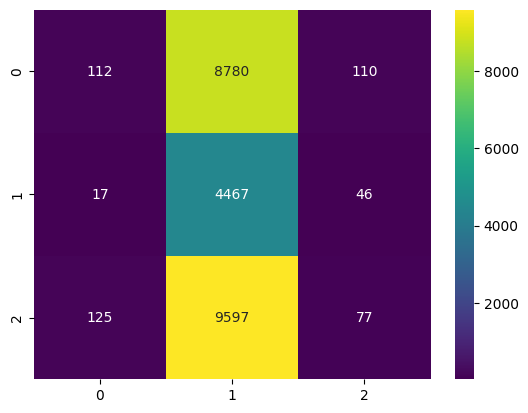

In [142]:
sns.heatmap(heatmap, annot=True, fmt='.0f', cmap='viridis')
print("Daily Precision", df_res[df_res['count'] > 0]['w_p'].mean())
print("Overal precision", (df_res['count_wp'].sum()/df_res['count'].sum()))
print("EV sum", df_res['ev'].sum())
print("Average count", df_res['count'].mean())
print("Active days: ", sum(df_res['count'] > 0) , "/", len(data_set_dict))

In [699]:
booster = models['long'][0].get_booster()
for i, tree_str in enumerate(booster.get_dump()):
    print(f"Tree {i}:\n{tree_str}\n")

Tree 0:
0:[ba_volrat_50<-0.272727281] yes=1,no=2,missing=2
	1:[lag_return_hat<-1.38633418] yes=3,no=4,missing=4
		3:leaf=0.573512793
		4:leaf=-0.281659275
	2:[_close_level<0.49751243] yes=5,no=6,missing=6
		5:leaf=-0.028874062
		6:leaf=0.0925333202


Tree 1:
0:[ba_volrat_50<-0.130434781] yes=1,no=2,missing=2
	1:[scaled_sparsity<0.295070112] yes=3,no=4,missing=4
		3:leaf=-0.168037802
		4:leaf=0.00504562724
	2:[p_movement_0.5<-0.52562499] yes=5,no=6,missing=6
		5:leaf=-0.0625070035
		6:leaf=0.0741934627


